In [20]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

# Logistic Regression
# Decision Tree
# Random Forest
# AdaBoost
# SGD Classifier
# XGBoost
# Feature Selection
# Scaling
# PCA
# Metrics

In [19]:
print="hello kaibalya"
print

'hello kaibalya'

In [21]:
!pip install xgboost

In [22]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier

from sklearn.linear_model import SGDClassifier

from xgboost import XGBClassifier

from sklearn.decomposition import PCA

from sklearn.feature_selection import RFE
from sklearn.feature_selection import SequentialFeatureSelector

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve
from sklearn.metrics import cohen_kappa_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

In [23]:
# Upload CSV first in Colab

df = pd.read_csv('/winequalityN.csv')

df.head()

,type,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,white,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6
1,white,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6
2,white,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6
3,white,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6
4,white,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6


In [24]:
(df.shape)

(6497, 13)

In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   type                  6497 non-null   object 
 1   fixed acidity         6487 non-null   float64
 2   volatile acidity      6489 non-null   float64
 3   citric acid           6494 non-null   float64
 4   residual sugar        6495 non-null   float64
 5   chlorides             6495 non-null   float64
 6   free sulfur dioxide   6497 non-null   float64
 7   total sulfur dioxide  6497 non-null   float64
 8   density               6497 non-null   float64
 9   pH                    6488 non-null   float64
 10  sulphates             6493 non-null   float64
 11  alcohol               6497 non-null   float64
 12  quality               6497 non-null   int64  
dtypes: float64(11), int64(1), object(1)
memory usage: 660.0+ KB


In [26]:
df.isnull().sum()

,0
type,0
fixed acidity,10
volatile acidity,8
citric acid,3
residual sugar,2
chlorides,2
free sulfur dioxide,0
total sulfur dioxide,0
density,0
pH,9


In [27]:
for col in df.columns:

    if df[col].dtype != 'object':

        df[col].fillna(df[col].median(), inplace=True)

/tmp/ipykernel_29616/2449387771.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)


In [28]:
df.isnull().sum()

,0
type,0
fixed acidity,0
volatile acidity,0
citric acid,0
residual sugar,0
chlorides,0
free sulfur dioxide,0
total sulfur dioxide,0
density,0
pH,0


In [29]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['type'] = le.fit_transform(df['type'])

df.head()

,type,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,1,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6
1,1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6
2,1,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6
3,1,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6
4,1,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6


In [30]:
import numpy as np

df['quality'] = np.where(df['quality'] >= 7, 1, 0)

df['quality'].value_counts()

,count
quality,
0,5220
1,1277


In [45]:
X = df.drop('quality', axis=1)

y = df['quality']

In [56]:
X_log = np.log1p(X)

In [58]:
ss = StandardScaler()

X_standard = ss.fit_transform(X_log)

In [59]:
mm = MinMaxScaler()

X_minmax = mm.fit_transform(X_standard)

In [61]:
pca = PCA(n_components=0.95)

X_pca = pca.fit_transform(X_minmax)

(X_pca.shape)

(6497, 7)

In [62]:
X_train, X_test, y_train, y_test = train_test_split(
    X_pca,
    y,
    test_size=0.2,
    random_state=42
)

In [63]:
lr = LogisticRegression()

forward = SequentialFeatureSelector(
    lr,
    n_features_to_select=5,
    direction='forward'
)

forward.fit(X, y)
(forward.get_support())

array([False, False, False, False,  True,  True,  True, False, False,
       False,  True,  True])

In [64]:
backward = SequentialFeatureSelector(
    lr,
    n_features_to_select=5,
    direction='backward'
)

backward.fit(X, y)

(backward.get_support())

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

array([False, False, False, False,  True,  True,  True, False, False,
       False,  True,  True])

In [67]:
rfe = RFE(
    estimator=LogisticRegression(),
    n_features_to_select=5
)

rfe.fit(X, y)

(rfe.support_)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

array([False, False,  True, False, False,  True, False, False, False,
        True,  True,  True])

In [68]:
lr = LogisticRegression()

lr.fit(X_train, y_train)

y_pred = lr.predict(X_test)

("Accuracy:", accuracy_score(y_test, y_pred))

('Accuracy:', 0.8207692307692308)

In [69]:
dt = DecisionTreeClassifier()

dt.fit(X_train, y_train)

y_pred = dt.predict(X_test)

("Accuracy:", accuracy_score(y_test, y_pred))

('Accuracy:', 0.8430769230769231)

In [70]:
rf = RandomForestClassifier()

rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)

("Accuracy:", accuracy_score(y_test, y_pred))

('Accuracy:', 0.8807692307692307)

In [72]:
ada = AdaBoostClassifier()

ada.fit(X_train, y_train)

y_pred = ada.predict(X_test)

("Accuracy:", accuracy_score(y_test, y_pred))

('Accuracy:', 0.8146153846153846)

In [73]:
sgd = SGDClassifier(loss='log_loss')

sgd.fit(X_train, y_train)

y_pred = sgd.predict(X_test)

("Accuracy:", accuracy_score(y_test, y_pred))

('Accuracy:', 0.8176923076923077)

In [74]:
xgb = XGBClassifier()

xgb.fit(X_train, y_train)

y_pred = xgb.predict(X_test)

("Accuracy:", accuracy_score(y_test, y_pred))

('Accuracy:', 0.8646153846153846)

In [77]:
("Precision:",
      precision_score(y_test, y_pred))

("Recall:",
      recall_score(y_test, y_pred))

("Kappa:",cohen_kappa_score(y_test, y_pred))

('Kappa:', np.float64(0.5223042971734946))

In [78]:
y_prob = rf.predict_proba(X_test)[:,1]

(roc_auc_score(y_test, y_prob))

np.float64(0.9054535639187439)

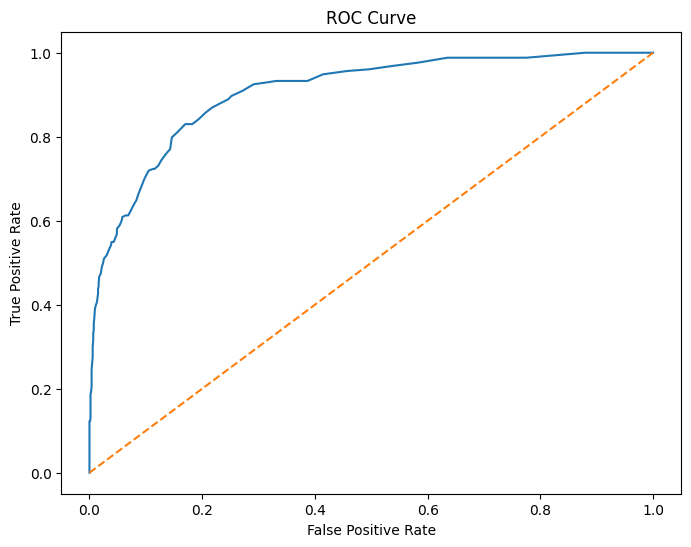

In [79]:
fpr, tpr, threshold = roc_curve(
    y_test,
    y_prob
)

plt.figure(figsize=(8,6))

plt.plot(fpr, tpr)

plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.show()

In [80]:
(confusion_matrix(y_test, y_pred))

array([[991,  56],
       [120, 133]])

In [81]:
(classification_report(y_test, y_pred))

'              precision    recall  f1-score   support\n\n           0       0.89      0.95      0.92      1047\n           1       0.70      0.53      0.60       253\n\n    accuracy                           0.86      1300\n   macro avg       0.80      0.74      0.76      1300\nweighted avg       0.86      0.86      0.86      1300\n'

Upload Dataset
↓
Import Libraries
↓
Handle Missing Values
↓
Encoding
↓
Log Transformation
↓
Scaling
↓
PCA
↓
Feature Selection
↓
Train Test Split
↓
Apply Models
↓
Evaluate Metrics
↓
ROC Curve
↓
Final Comparison

